# Team Standings Model

In [1]:
# For data handling
import pandas as pd
import numpy as np

# To manage model loading and save paths
import os
import json
import joblib
from datetime import datetime

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Machine Learning
from sklearn import tree, svm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier

In [2]:
# Creating a timestamp for saving model version number by date
timestamp = datetime.now().strftime("%Y_%m_%d")

# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/teams_cleaned"
PROCESSED_PATH = "../../data/processed"
ML_PATH = "../../models/ml"
DL_PATH = "../../models/dl"
os.makedirs(ML_PATH, exist_ok=True)
os.makedirs(DL_PATH, exist_ok=True)

# Create a timestamped subdirectory inside DL and ML Path
versioned_dl_path = os.path.join(DL_PATH, f"best_team_{timestamp}")
os.makedirs(versioned_dl_path, exist_ok=True)

versioned_ml_path = os.path.join(ML_PATH, f"best_team_{timestamp}")
os.makedirs(versioned_ml_path, exist_ok=True)

In [3]:
team_df = pd.read_csv(f"{PROCESSED_PATH}/team_eda_cleaned.csv")

In [4]:
team_df.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
all_seasons_df = pd.read_csv(f"{CLEANED_PATH}/team_all_years.csv")

In [6]:
team_df.index.equals(all_seasons_df.index)

True

In [7]:
# Creating a helper column for determing the best record in a season
all_seasons_df["Max_Wins"] = all_seasons_df.groupby("Season")["W"].transform("max")

In [8]:
# Creating the has_Best_Record column
all_seasons_df["has_Best_Record"] = all_seasons_df["W"] == all_seasons_df["Max_Wins"]

In [9]:
# Dropping the Max Wins column as it's no longer needed
all_seasons_df.drop(columns=["Max_Wins"], inplace=True)

In [10]:
selected_features = list(team_df.drop(columns=["has_Best_Record"]).columns)
reduced_with_season = all_seasons_df[selected_features + ["Season", "has_Best_Record"]].dropna()

In [11]:
# Checking to see if indexes match before merging
team_df.index.equals(reduced_with_season.index)

True

In [12]:
# Merging the DataFrames
team_df["Season"] = reduced_with_season["Season"]

In [13]:
team_df.head(5)

,MOV,3P%,DRB,FG%,ORtg,BLK,AST,FG,PTS,3P,DRB%,has_Best_Record,Season
0,4.90,0.412,31.9,0.492,115.3,5.1,23.3,40.7,110.2,8.9,70.8,0,2010
1,-3.60,0.375,29.2,0.469,108.1,4.1,22.4,40.6,108.8,7.7,68.5,0,2010
2,4.09,0.359,30.5,0.468,111.8,5.1,21.0,38.1,106.5,6.6,72.4,0,2010
3,5.34,0.364,31.6,0.491,110.7,4.9,26.7,39.4,104.2,5.4,75.6,0,2010
4,-1.78,0.371,30.6,0.482,111.3,4.7,22.0,39.0,104.1,6.3,72.9,0,2010


In [14]:
team_df.tail(5)

,MOV,3P%,DRB,FG%,ORtg,BLK,AST,FG,PTS,3P,DRB%,has_Best_Record,Season
445,1.76,0.370,33.0,0.465,114.0,3.4,25.8,39.8,110.1,12.5,78.1,0,2024
446,-9.11,0.348,32.8,0.463,109.7,4.7,25.5,40.9,109.9,11.0,77.3,0,2024
447,-10.24,0.355,31.0,0.460,109.3,4.5,24.8,40.0,106.6,12.1,74.5,0,2024
448,-9.02,0.345,30.1,0.439,108.3,4.3,23.1,39.4,106.4,11.5,74.0,0,2024
449,-7.00,0.346,31.7,0.435,107.2,6.1,24.7,38.4,105.8,13.1,74.8,0,2024


In [15]:
print(team_df.isnull().sum())

MOV                0
3P%                0
DRB                0
FG%                0
ORtg               0
BLK                0
AST                0
FG                 0
PTS                0
3P                 0
DRB%               0
has_Best_Record    0
Season             0
dtype: int64


## Machine Learning Portion


In [16]:
X = team_df.drop(columns=["has_Best_Record", "Season"])
y = team_df["has_Best_Record"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

In [18]:
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled_lr, y_train)
y_pred_lr = model_lr.predict(X_test_scaled_lr)

In [19]:
# Model results
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[86  0]
 [ 2  2]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        86
           1       1.00      0.50      0.67         4

    accuracy                           0.98        90
   macro avg       0.99      0.75      0.83        90
weighted avg       0.98      0.98      0.97        90



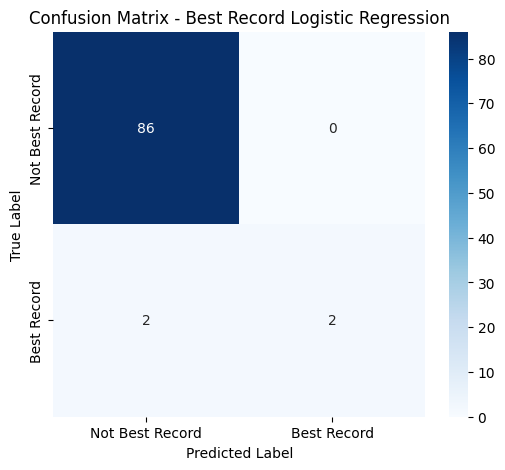

In [20]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Best Record", "Best Record"],
            yticklabels=["Not Best Record", "Best Record"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Best Record Logistic Regression")
plt.show()

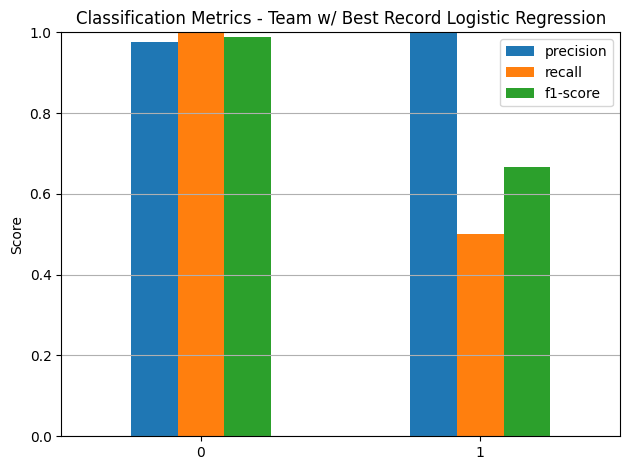

In [21]:
report = classification_report(y_test, y_pred_lr, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Bar chart for precision, recall and f1-score
df_report.iloc[:2][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Classification Metrics - Team w/ Best Record Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [22]:
scaler_clf = MinMaxScaler()
X_train_scaled_clf = scaler_clf.fit_transform(X_train)
X_test_scaled_clf = scaler_clf.transform(X_test)

In [23]:
model_clf = tree.DecisionTreeClassifier(class_weight="balanced")
model_clf.fit(X_train_scaled_clf, y_train)
y_pred_clf = model_lr.predict(X_test_scaled_clf)

[Text(0.36363636363636365, 0.9285714285714286, 'x[0] <= 0.808\ngini = 0.5\nsamples = 360\nvalue = [180.0, 180.0]'),
 Text(0.18181818181818182, 0.7857142857142857, 'x[5] <= 0.052\ngini = 0.0\nsamples = 338\nvalue = [174.828, 0.0]'),
 Text(0.2727272727272727, 0.8571428571428572, 'True  '),
 Text(0.09090909090909091, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0.517, 0.0]'),
 Text(0.2727272727272727, 0.6428571428571429, 'gini = 0.0\nsamples = 337\nvalue = [174.31, 0.0]'),
 Text(0.5454545454545454, 0.7857142857142857, 'x[6] <= 0.27\ngini = 0.054\nsamples = 22\nvalue = [5.172, 180.0]'),
 Text(0.45454545454545453, 0.8571428571428572, '  False'),
 Text(0.45454545454545453, 0.6428571428571429, 'gini = 0.0\nsamples = 3\nvalue = [1.552, 0.0]'),
 Text(0.6363636363636364, 0.6428571428571429, 'x[10] <= 0.324\ngini = 0.039\nsamples = 19\nvalue = [3.621, 180.0]'),
 Text(0.5454545454545454, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0.517, 0.0]'),
 Text(0.7272727272727273, 0.5, 'x[7] <= 0.797\

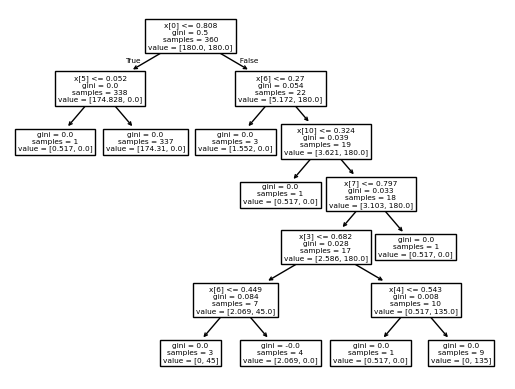

In [24]:
tree.plot_tree(model_clf)

In [25]:
# Model results
print(confusion_matrix(y_test, y_pred_clf))
print(classification_report(y_test, y_pred_clf))

[[86  0]
 [ 4  0]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        86
           1       0.00      0.00      0.00         4

    accuracy                           0.96        90
   macro avg       0.48      0.50      0.49        90
weighted avg       0.91      0.96      0.93        90



c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter t

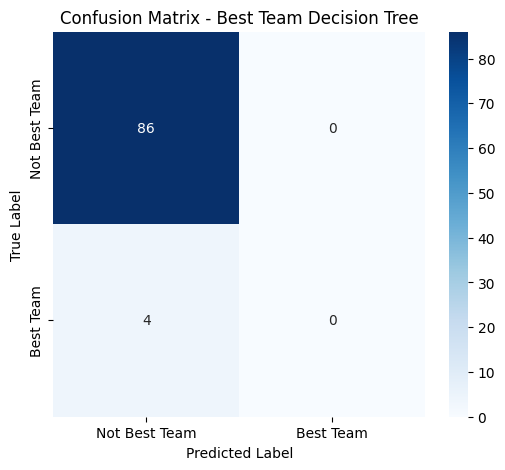

In [26]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_clf)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Best Team", "Best Team"],
            yticklabels=["Not Best Team", "Best Team"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Best Team Decision Tree")
plt.show()

## Deep Learning Portion

In [27]:
# Setting train, test, splits for deep learning approach
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_test_nn = scaler_nn.transform(X_test_nn)

In [29]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_nn.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [30]:
class BESTNET(nn.Module):
    """
    A feedforward neural network for predicting NBA' Best Team likelihood based on team stats.

    Args:
        input_dim (int): Number of input features
    """
    def __init__(self, input_dim):
        """
        Initializes the BESTNet model with a series of fully connected layers,
        LeakyReLu activations, and dropout regularization.

        Args:
            input_dim (int): Number of input features
        """
        super(BESTNET, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), # The expanding architecture
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            
            nn.Linear(16, 1),
            
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)
            
        Returns:
            torch.Tensor: Output tensor with shape (batch_size, 1), representing Best Team prediction scores.
        """
        
        return self.network(x)
        

In [31]:
# Calculate class counts (assuming y_train is a pandas Series or NumPy array)
neg = (y_train_nn == 0).sum()
pos = (y_train_nn == 1).sum()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute pos_weight = (# of negative samples / # of positive samples)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

In [32]:
# Model training
model_nn = BESTNET(input_dim=X_train_nn.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

num_epochs = 200
model_nn.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_nn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

Epoch 1/200, Loss: 15.5353
Epoch 2/200, Loss: 15.0458
Epoch 3/200, Loss: 13.9347
Epoch 4/200, Loss: 11.9148
Epoch 5/200, Loss: 9.8701
Epoch 6/200, Loss: 10.5895
Epoch 7/200, Loss: 7.7926
Epoch 8/200, Loss: 5.4813
Epoch 9/200, Loss: 4.1817
Epoch 10/200, Loss: 4.7684
Epoch 11/200, Loss: 4.3039
Epoch 12/200, Loss: 5.3508
Epoch 13/200, Loss: 3.2368
Epoch 14/200, Loss: 3.9107
Epoch 15/200, Loss: 2.7781
Epoch 16/200, Loss: 2.5118
Epoch 17/200, Loss: 3.0192
Epoch 18/200, Loss: 2.3718
Epoch 19/200, Loss: 2.5747
Epoch 20/200, Loss: 3.5575
Epoch 21/200, Loss: 2.3168
Epoch 22/200, Loss: 2.3653
Epoch 23/200, Loss: 2.8330
Epoch 24/200, Loss: 3.1731
Epoch 25/200, Loss: 2.0255
Epoch 26/200, Loss: 1.7832
Epoch 27/200, Loss: 2.8610
Epoch 28/200, Loss: 2.3601
Epoch 29/200, Loss: 1.9861
Epoch 30/200, Loss: 2.0016
Epoch 31/200, Loss: 1.5287
Epoch 32/200, Loss: 2.0227
Epoch 33/200, Loss: 1.9988
Epoch 34/200, Loss: 1.7896
Epoch 35/200, Loss: 1.7048
Epoch 36/200, Loss: 1.3735
Epoch 37/200, Loss: 2.9097
Epoch

In [33]:
model_nn.eval()
prob_threshold = 1 / (1 + np.exp(-7.0))

with torch.no_grad():
    y_pred_probs_nn = model_nn(X_test_tensor.to(device)).cpu().numpy()
    y_pred_nn = (y_pred_probs_nn > prob_threshold).astype(int)

print(confusion_matrix(y_test_nn, y_pred_nn))
print(classification_report(y_test_nn, y_pred_nn))

[[85  1]
 [ 2  2]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        86
           1       0.67      0.50      0.57         4

    accuracy                           0.97        90
   macro avg       0.82      0.74      0.78        90
weighted avg       0.96      0.97      0.96        90



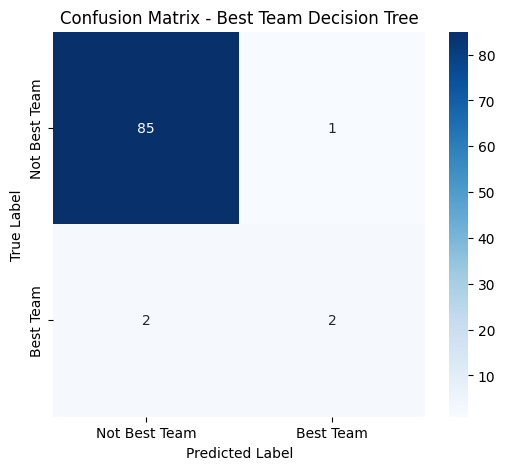

In [34]:
# Computing confusion matrix
cm = confusion_matrix(y_test_nn, y_pred_nn)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Best Team", "Best Team"],
            yticklabels=["Not Best Team", "Best Team"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Best Team Decision Tree")
plt.show()

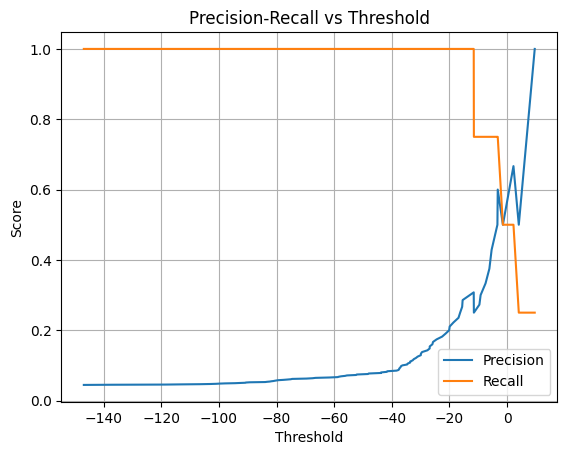

In [35]:
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(y_test, y_pred_probs_nn)

plt.plot(thresholds_nn, precision_nn[:-1], label='Precision')
plt.plot(thresholds_nn, recall_nn[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

## Model completion

In [36]:
def predict_best_team(
    model: torch.nn.Module,
    data: pd.DataFrame,
    feature_columns: list[str],
    team_id_column: str,
    threshold: float,
    scaler: object,
    device: torch.device = torch.device("cpu"),
    return_probs: bool = True
) -> pd.DataFrame:
    """
    
    Use a trained PyTorch model to predict Best Team from unlabeled data

    Args:
        model (torch.nn.Module): Trained PyTorch model (no final sigmoid)
        data (pd.DataFrame): Input DataFrame with team-season stats
        feature_columns (list[str]): List of columns used as features
        team_id_column (str): Column name for identifying teams
        threshold (float): Logit threshold to label a team as the Best Team
        scaler (object): Scaler used during model training
        device (torch.device): CPU or GPU. Defaults to CPU
        return_probs (bool): If True, include predicted logit and probability columns

    Returns:
        pd.DataFrame: Subset of input data predicted as Best Team, with optional confidence scores

    """
    model.eval()
    
    # Preprocess input features
    X = scaler.transform(data[feature_columns])
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    
    # Get logits from model
    with torch.no_grad():
        logits = model(X_tensor).cpu().numpy().flatten()
    
    # Apply threshold to get binary predictions
    predictions = (logits > threshold).astype(int)
    
    # Append predictions and optional scores
    data = data.copy()
    data["predicted_best_team"] = predictions

    if return_probs:
        data["logit"] = logits
        data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid
    
    # Filter to PPG Leader candidates
    best_team = data[data["predicted_best_team"] == 1].sort_values(by="logit", ascending=False)

    return best_team

In [37]:
# Loading a cleaned dataset that is not scaled
all_season_df = pd.read_csv(f"{CLEANED_PATH}/team_all_years.csv")

all_season_df.drop(columns=["W", "L"], inplace=True)


In [38]:
feature_list = [
    "MOV", "3P%", "DRB", "FG%",
    "ORtg", "BLK", "AST", "FG",
    "PTS", "3P", "DRB%"  
]

Actual Best records by season:
* 08-09	Cleveland Cavaliers	66-16	
* 09-10	Cleveland Cavaliers	61-21	
* 10-11	Chicago Bulls	62-20	
* 11-12	Chicago Bulls	50-16	
* 12-13 San Antonio Spurs	50-16	
* 12-13	Miami Heat	66-16	
* 13-14	San Antonio Spurs	
* 14-15	Golden State Warriors	
* 15-16	Golden State Warriors	
* 16-17	Golden State Warriors	
* 17-18	Houston Rockets	65-17	
* 18-19	Milwaukee Bucks	60-22	
* 19-20	Milwaukee Bucks	56-17	
* 20-21	Utah Jazz	52-20	
* 21-22	Phoenix Suns	64-18	
* 22-23	Milwaukee Bucks	58-24	
* 23-24	Boston Celtics	64-18	
* 24-25	Oklahoma City Thunder 68-14

In [39]:
best_team = predict_best_team(
    model=model_nn,
    data=all_season_df,
    feature_columns=feature_list,
    team_id_column="Team",  
    threshold=7.0,
    scaler=scaler_nn,
    device=device
)

print(best_team[["Team", "logit", "probability", "Season"]].head(10))

                      Team      logit  probability  Season
94              Miami Heat  13.565074     0.999999    2013
300        Milwaukee Bucks  11.627985     0.999991    2020
180  Golden State Warriors   9.602729     0.999932    2016
270        Milwaukee Bucks   8.538938     0.999804    2019
150  Golden State Warriors   8.233708     0.999734    2015
49           Chicago Bulls   8.156539     0.999713    2011
61       San Antonio Spurs   7.563014     0.999481    2012
421         Boston Celtics   7.075125     0.999155    2024


C:\Users\bartl\AppData\Local\Temp\ipykernel_60156\3178327804.py:48: RuntimeWarning: overflow encountered in exp
  data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid


In [40]:
# Deep Learning Model Save
model_path = os.path.join(versioned_dl_path, "best_team_model_weights.pth")
torch.save(model_nn.state_dict(), model_path)

# Deep Learning Scaler save
scaler_path = os.path.join(versioned_dl_path, "best_team_scaler.pkl")
joblib.dump(scaler_nn, scaler_path)

# Features and metadata save
feature_list_path = os.path.join(versioned_dl_path, "best_team_feature_list.json")
metadata = {
    "timestamp": timestamp,
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 7.0,
    "notes" : "Deep learning Best Team prediction model trained on all-season data"
}

# Feature list save

with open(feature_list_path, "w") as f:
    json.dump(metadata, f, indent=4)


In [41]:
# Machine Learning Model save
ml_model_path = os.path.join(versioned_ml_path, "best_team_model.pkl")
joblib.dump(model_lr, ml_model_path)

# Machine Learning Scaler save
ml_scaler_path = os.path.join(versioned_ml_path, "best_team_scaler.pkl")
joblib.dump(scaler_lr, ml_scaler_path)

# Metadata save

ml_metadata = {
    "timestamp": timestamp,
    "model_type" : str(type(model_lr)).split("'")[1],
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 0.5,
    "notes" : "Best Machine Learning Model for Best Team prediction"
}

ml_metadata_path = os.path.join(versioned_ml_path, "best_team_feature_list.json")
with open(ml_metadata_path, "w") as f:
    json.dump(ml_metadata, f, indent=4)
